In [57]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Поставување на визуелен стил за презентацијата
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print(" Библиотеките се успешно вчитани.")

 Библиотеките се успешно вчитани.


# EDA

In [58]:
# Со промена само на оваа променлива, целиот notebook се прилагодува за нова компанија!
TICKER = 'TSLA' 

base_dir = os.getcwd()
file_path = os.path.join(base_dir, '..', 'data', 'raw', 'sp500_stocks.csv')

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Базата не е пронајдена на патеката: {file_path}")

raw_df = pd.read_csv(file_path)

# Чистење на празни места (spaces) од колоните и тикерите
raw_df.columns = raw_df.columns.str.strip()
raw_df['Symbol'] = raw_df['Symbol'].astype(str).str.strip()

# Филтрирање и хронолошко сортирање
df = raw_df[raw_df['Symbol'].str.upper() == TICKER.upper()].copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f" Првично филтрирани редови за {TICKER}: {df.shape[0]}")

# Отстранување на NaN вредности во критичната колона 'Close'
df.dropna(subset=['Close'], inplace=True)
df = df.reset_index(drop=True)

print(f" Редови по елиминација на празни цени: {df.shape[0]}")
df.head()

 Првично филтрирани редови за TSLA: 3768
 Редови по елиминација на празни цени: 3646


,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-06-29,TSLA,1.592667,1.592667,1.666667,1.169333,1.266667,281494500.0
1,2010-06-30,TSLA,1.588667,1.588667,2.028000,1.553333,1.719333,257806500.0
2,2010-07-01,TSLA,1.464000,1.464000,1.728000,1.351333,1.666667,123282000.0
3,2010-07-02,TSLA,1.280000,1.280000,1.540000,1.247333,1.533333,77097000.0
4,2010-07-06,TSLA,1.074000,1.074000,1.333333,1.055333,1.333333,103003500.0


In [59]:
print("--- Проверка на типови на податоци ---")
print(df.info())

print("\n--- Проверка за преостанати Missing Values ---")
print(df.isnull().sum())

print("\n--- Дескриптивна статистика (Мерки на централна тенденција) ---")
df.describe()

--- Проверка на типови на податоци ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3646 entries, 0 to 3645
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       3646 non-null   datetime64[ns]
 1   Symbol     3646 non-null   object        
 2   Adj Close  3646 non-null   float64       
 3   Close      3646 non-null   float64       
 4   High       3646 non-null   float64       
 5   Low        3646 non-null   float64       
 6   Open       3646 non-null   float64       
 7   Volume     3646 non-null   float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 228.0+ KB
None

--- Проверка за преостанати Missing Values ---
Date         0
Symbol       0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

--- Дескриптивна статистика (Мерки на централна тенденција) ---


,Date,Adj Close,Close,High,Low,Open,Volume
count,3646,3646.000000,3646.000000,3646.000000,3646.000000,3646.000000,3.646000e+03
mean,2017-09-24 00:49:22.150301696,80.945549,80.945549,82.738600,79.063571,80.954785,9.671530e+07
min,2010-06-29 00:00:00,1.053333,1.053333,1.108667,0.998667,1.076000,1.777500e+06
25%,2014-02-11 06:00:00,12.094667,12.094667,12.326666,11.802333,12.088333,4.899225e+07
50%,2017-09-23 12:00:00,17.871334,17.871334,18.154000,17.605000,17.915001,8.206870e+07
75%,2021-05-09 06:00:00,177.579998,177.579998,181.355000,173.797504,177.200005,1.224334e+08
max,2024-12-20 00:00:00,479.859985,479.859985,488.540009,457.510010,475.899994,9.140820e+08
std,NaN,106.753414,106.753414,109.210702,104.199898,106.799649,7.778778e+07


# Detecting Outliers

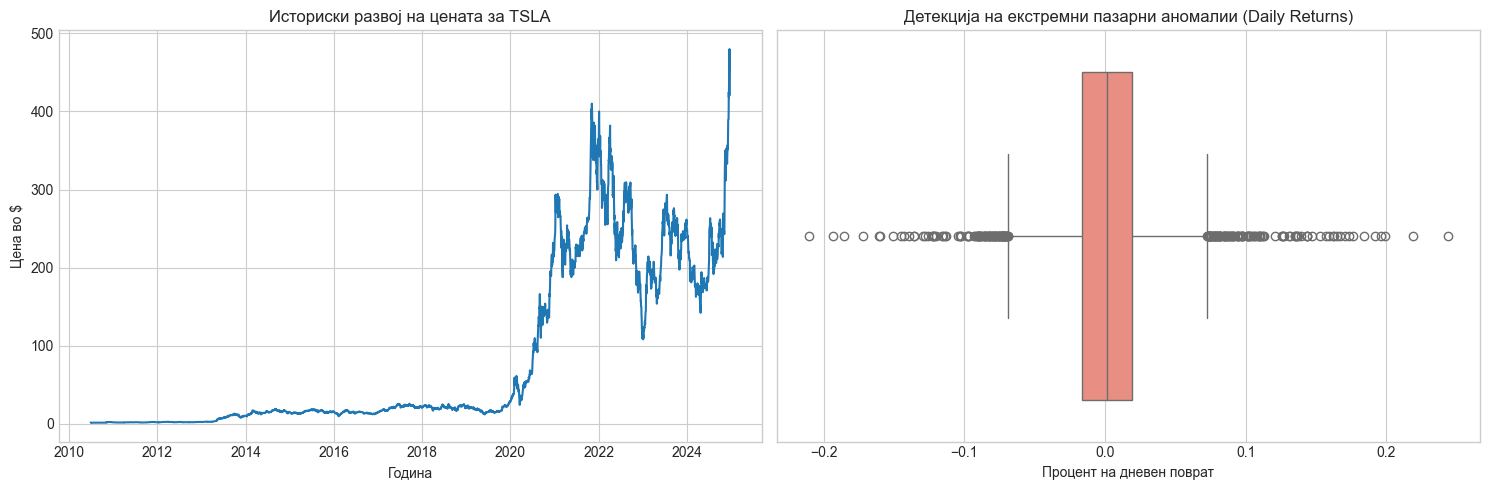

In [60]:
# Пресметуваме дневен поврат бидејќи суровата цена не е стационарна и лажира аутлаери
df['Daily_Return_Raw'] = df['Close'].pct_change().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Линeарен график за историски тренд
ax[0].plot(df['Date'], df['Close'], color='tab:blue', linewidth=1.5, label='Close Price')
ax[0].set_title(f"Историски развој на цената за {TICKER}", fontsize=12)
ax[0].set_ylabel("Цена во $")
ax[0].set_xlabel("Година")

# Boxplot за принос
sns.boxplot(x=df['Daily_Return_Raw'], ax=ax[1], color='salmon')
ax[1].set_title("Детекција на екстремни пазарни аномалии (Daily Returns)", fontsize=12)
ax[1].set_xlabel("Процент на дневен поврат")

plt.tight_layout()
plt.show()

# IQR

In [61]:
Q1 = df['Daily_Return_Raw'].quantile(0.25)
Q3 = df['Daily_Return_Raw'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Daily_Return_Raw'] < lower_bound) | (df['Daily_Return_Raw'] > upper_bound)]
print(f" IQR детекција: Пронајдени се {outliers.shape[0]} денови со екстремни пазарни шокови.")

# Применуваме 'Capping' (лимитирање) за да го зачуваме временскиот континуитет без бришење редови
df['Daily_Return_Cleaned'] = df['Daily_Return_Raw'].clip(lower=lower_bound, upper=upper_bound)
df.drop(columns=['Daily_Return_Raw'], inplace=True)
print(f" Успешно извршено мазнење на аномалиите во опсег [{lower_bound:.4f}, {upper_bound:.4f}].")

 IQR детекција: Пронајдени се 203 денови со екстремни пазарни шокови.
 Успешно извршено мазнење на аномалиите во опсег [-0.0692, 0.0726].


# Feature Engineering & Window Size)

In [62]:
def build_optimized_features(data, window_short=7, window_long=21):
    data = data.copy()
    
    # Генерирање базни прозорци
    data['MA_7'] = data['Close'].rolling(window=window_short).mean()
    data['MA_21'] = data['Close'].rolling(window=window_long).mean()
    data['EMA_12'] = data['Close'].ewm(span=12, adjust=False).mean()
    data['EMA_26'] = data['Close'].ewm(span=26, adjust=False).mean()
    
    # КРЕИРАЊЕ НА НЕКОРЕЛИРАНИ КАРАКТЕРИСТИКИ (Го решаваме проблемот со мултиколинеарност)
    data['MA_Trend_Diff'] = data['MA_7'] - data['MA_21']
    data['EMA_Spread'] = data['EMA_12'] - data['EMA_26']
    data['Price_to_MA7_Ratio'] = data['Close'] / (data['MA_7'] + 1e-9)
    
    # Пазарна динамика (Волатилност и Моментум)
    data['Volatility'] = data['Daily_Return_Cleaned'].rolling(window=window_short).std()
    
    # RSI Индикатор
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-9)
    data['RSI'] = 100 - (100 / (1 + rs))
    
    # ДЕФИНИРАЊЕ НА ТАРГЕТ (y_t = Цена во денот t+1)
    data['Target_Price'] = data['Close'].shift(-1)
    
    data.dropna(inplace=True)
    return data

df_ml = build_optimized_features(df)
print(f" Матрицата за Машинско Учење е подготвена. Димензии: {df_ml.shape}")

 Матрицата за Машинско Учење е подготвена. Димензии: (3625, 19)


# Correlation Matrix

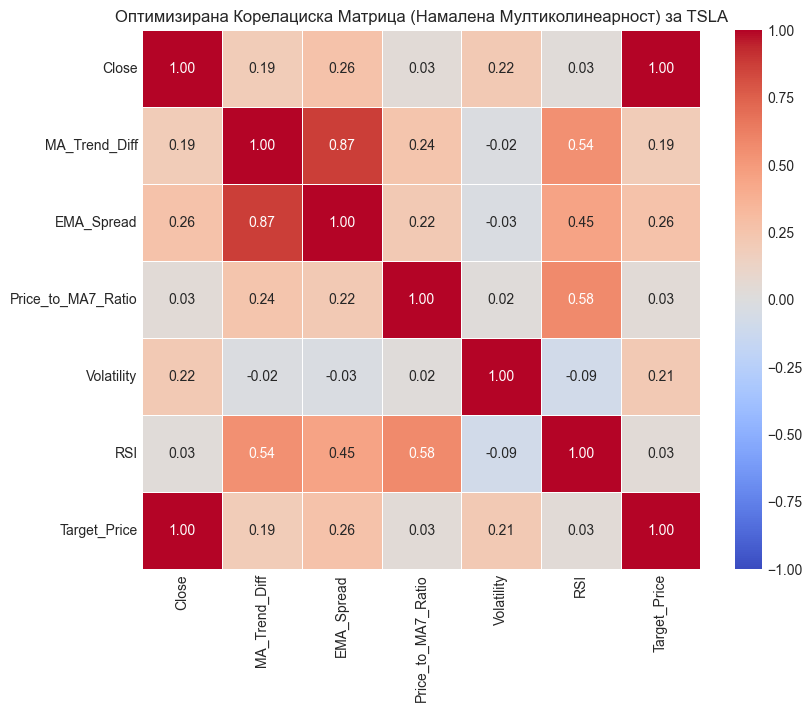

In [63]:
# Овде ги изнајдовме само најважните, независни карактеристики за да го задоволиме барањето на професорот
optimized_features = ['Close', 'MA_Trend_Diff', 'EMA_Spread', 'Price_to_MA7_Ratio', 'Volatility', 'RSI', 'Target_Price']

plt.figure(figsize=(9, 7))
corr_matrix = df_ml[optimized_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title(f"Оптимизирана Корелациска Матрица (Намалена Мултиколинеарност) за {TICKER}")
plt.show()

# Train-Test Split

 Големина на тренинг фаза (Минато): 2900 денови
 Големина на тест фаза (Иднина): 725 денови


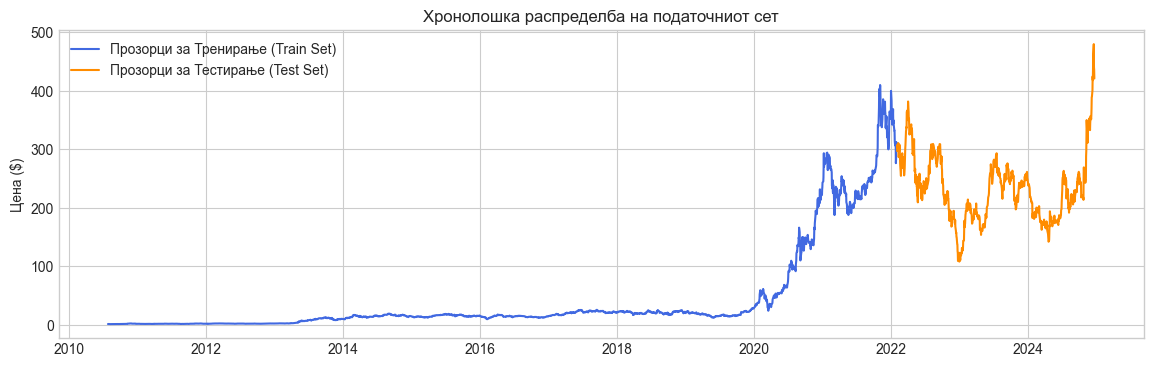

In [64]:
# Ги селектираме карактеристиките БЕЗ суровите MA_7, MA_21 бидејќи нивните разлики се веќе внатре
# Ова е клучно за Временски Серии - Ги земаме САМО изведените индикатори
X = df_ml.drop(columns=['Date', 'Symbol', 'Target_Price', 'Close'])  # Го додадовме 'Close' тука
y = df_ml['Target_Price']

# 80% за тренирање, 20% за тест период (хронолошки)
split_idx = int(len(df_ml) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f" Големина на тренинг фаза (Минато): {X_train.shape[0]} денови")
print(f" Големина на тест фаза (Иднина): {X_test.shape[0]} денови")

# Визуелен приказ на поделбата на сетот
plt.figure(figsize=(14, 4))
plt.plot(df_ml['Date'].iloc[:split_idx], y_train, label='Прозорци за Тренирање (Train Set)', color='royalblue')
plt.plot(df_ml['Date'].iloc[split_idx:], y_test, label='Прозорци за Тестирање (Test Set)', color='darkorange')
plt.title("Хронолошка распределба на податочниот сет")
plt.ylabel("Цена ($)")
plt.legend()
plt.show()

In [65]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Карактеристиките се успешно скалурани околу нивната средна вредност.")

 Карактеристиките се успешно скалурани околу нивната средна вредност.


In [66]:
print("Иницијализација и тренирање на алгоритмите...")

all_models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=7),
    "SVM": SVR(kernel='rbf', C=10.0, epsilon=0.05),
    "XGBoost": XGBRegressor(n_estimators=150, learning_rate=0.03, max_depth=4, random_state=42)
}

for name, model in all_models.items():
    model.fit(X_train_scaled, y_train)
    print(f" [УСПЕШНО] Моделот '{name}' заврши со тренирање.")

Иницијализација и тренирање на алгоритмите...
 [УСПЕШНО] Моделот 'Random Forest' заврши со тренирање.
 [УСПЕШНО] Моделот 'KNN' заврши со тренирање.
 [УСПЕШНО] Моделот 'SVM' заврши со тренирање.
 [УСПЕШНО] Моделот 'XGBoost' заврши со тренирање.


In [67]:
comparison_results = {}

for name, model in all_models.items():
    preds = model.predict(X_test_scaled)
    
    # Калкулација на статистички грешки
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    
    comparison_results[name] = {
        "MAE ($)": round(mae, 2),
        "RMSE ($)": round(rmse, 2),
        "R² Score (%)": round(r2 * 100, 2)
    }

df_comparison = pd.DataFrame(comparison_results).T

print("\n=======================================================")
print("     ФИНАЛЕН ИЗВЕШТАЈ ОД ЕВАЛУАЦИЈА НА СИТЕ МОДЕЛИ    ")
print("=======================================================")
# Сортирање според најмала средна апсолутна грешка (Победникот излегува прв)
display(df_comparison.sort_values(by="MAE ($)", ascending=True))
print("=======================================================")


     ФИНАЛЕН ИЗВЕШТАЈ ОД ЕВАЛУАЦИЈА НА СИТЕ МОДЕЛИ    


,MAE ($),RMSE ($),R² Score (%)
XGBoost,8.58,12.61,95.07
Random Forest,10.25,13.94,93.97
KNN,20.46,26.92,77.54
SVM,21.60,42.83,43.13


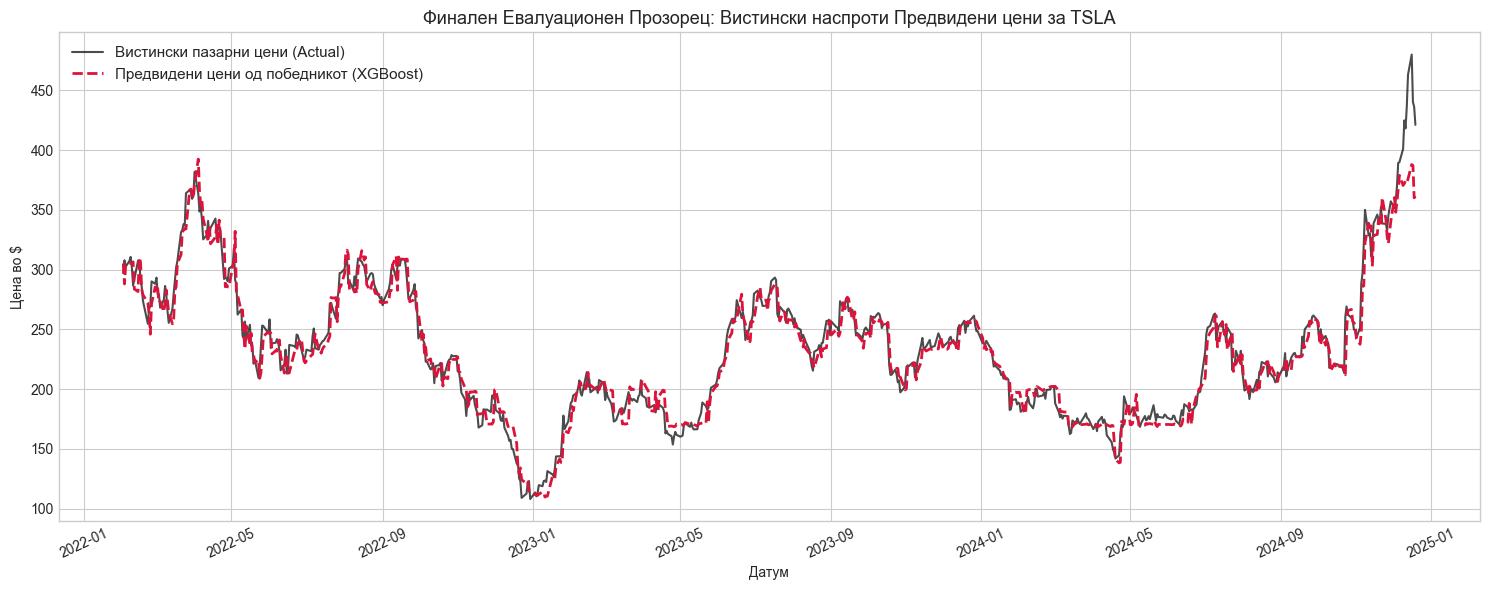

In [68]:
# Автоматски го идентификуваме моделот со најдобар (најнизок) MAE резултат
best_model_name = df_comparison["MAE ($)"].idxmin()
best_model = all_models[best_model_name]
best_preds = best_model.predict(X_test_scaled)

plt.figure(figsize=(15, 6))
test_dates = df_ml['Date'].iloc[split_idx:]

# Исцртување на кривите
plt.plot(test_dates, y_test.values, label="Вистински пазарни цени (Actual)", color='black', linewidth=1.5, alpha=0.7)
plt.plot(test_dates, best_preds, label=f"Предвидени цени од победникот ({best_model_name})", color='crimson', linestyle='--', linewidth=2)

plt.title(f"Финален Евалуационен Прозорец: Вистински наспроти Предвидени цени за {TICKER}", fontsize=13)
plt.xlabel("Датум")
plt.ylabel("Цена во $")
plt.legend(fontsize=11)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [69]:
# Специфична анализа за XGBoost за да ги извлечеме неговите карактеристики на важност
xgb_internal = all_models["XGBoost"]
xgb_preds = xgb_internal.predict(X_test_scaled)

xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

print("=============================================")
print(f"      СТАТИСТИКА СПЕЦИФИЧНО ЗА XGBOOST       ")
print("=============================================")
print(f"Mean Absolute Error (MAE):       ${xgb_mae:.2f}")
print(f"Root Mean Squared Error (RMSE):  ${xgb_rmse:.2f}")
print(f"R² Score (Објаснета варијанса):  {xgb_r2 * 100:.2f}%")
print("=============================================")

      СТАТИСТИКА СПЕЦИФИЧНО ЗА XGBOOST       
Mean Absolute Error (MAE):       $8.58
Root Mean Squared Error (RMSE):  $12.61
R² Score (Објаснета варијанса):  95.07%


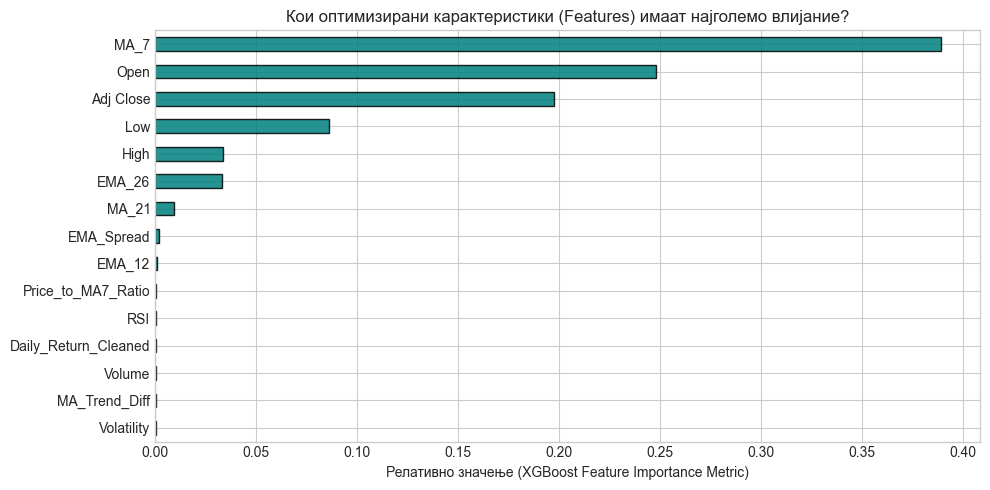

In [70]:
importance = xgb_internal.feature_importances_
# Овде index=X.columns совршено одговара на новите 6 оптимизирани колони
feat_imp_series = pd.Series(importance, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
feat_imp_series.plot(kind='barh', color='teal', edgecolor='black', alpha=0.85)

plt.title("Кои оптимизирани карактеристики (Features) имаат најголемо влијание?")
plt.xlabel("Релативно значење (XGBoost Feature Importance Metric)")
plt.tight_layout()
plt.show()

  РЕЗУЛТАТИ ДЕН-ПО-ДЕН ЗА ЈАНУАРИ 2024 СО XGBOOST 


,Датум,Вистинска Цена ($),Предвидена Цена ($),Разлика/Грешка ($),Апсолутна Грешка ($)
0,2024-01-02,238.45,242.970001,4.52,4.52
1,2024-01-03,237.93,234.210007,-3.72,3.72
2,2024-01-04,237.49,236.809998,-0.68,0.68
3,2024-01-05,240.45,233.009995,-7.44,7.44
4,2024-01-08,234.96,235.429993,0.47,0.47
5,2024-01-09,233.94,231.009995,-2.93,2.93
6,2024-01-10,227.22,231.740005,4.52,4.52
7,2024-01-11,218.89,223.779999,4.89,4.89
8,2024-01-12,219.91,221.750000,1.84,1.84
9,2024-01-16,215.55,219.039993,3.49,3.49



💡 Просечна утка на моделот за Јануари 2024: $5.00


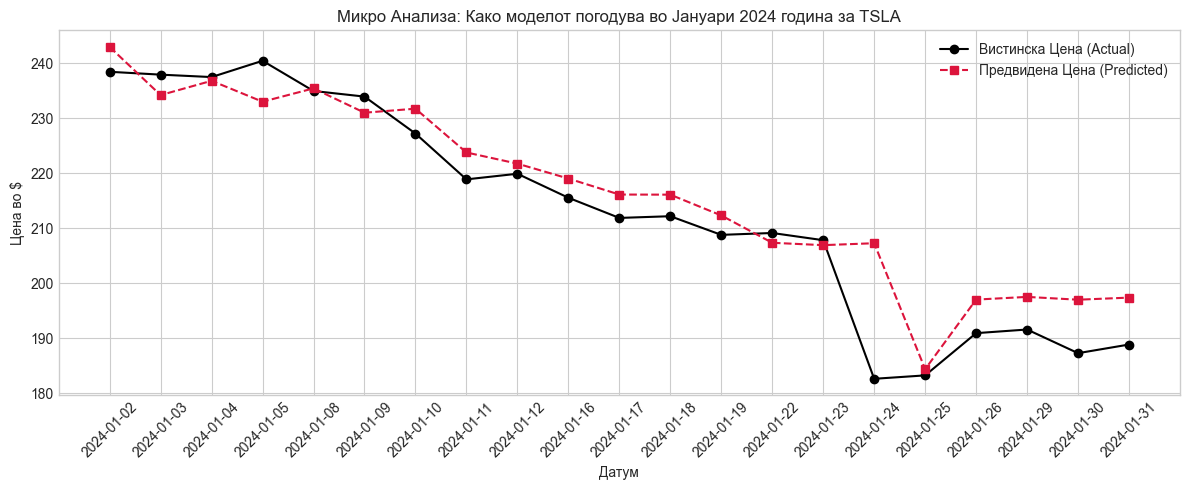

In [73]:
# --- НАПРЕДЕН ТЕСТ: Квалитет на предвидување за Јануари 2024 ---

# 1. Филтрирање на тест сетот за Јануари 2024 година
test_df_with_dates = df_ml.iloc[split_idx:].copy() # Го земаме само тест сетот
jan_2024_mask = (test_df_with_dates['Date'] >= '2024-01-01') & (test_df_with_dates['Date'] <= '2024-01-31')
jan_2024_df = test_df_with_dates[jan_2024_mask]

if jan_2024_df.empty:
    print("❌ Внимание: Нема податоци за Јануари 2024 во тест сетот. Проверете дали сплитот (80:20) го опфаќа овој период.")
else:
    # 2. Изолирање на индекс позициите за да ги земеме точните скалувани карактеристики (X_test_scaled)
    jan_indices = jan_2024_df.index - test_df_with_dates.index[0]
    X_jan_scaled = X_test_scaled[jan_indices]
    
    # 3. ПОПРАВЕНО: Извлекување на името на победничкиот модел преку правилна синтакса со загради []
    winner_model_name = df_comparison.drop("Naïve Baseline (Референца)", errors='ignore')["MAE ($)"].idxmin()
    winner_model = all_models[winner_model_name]
    
    # 4. Предвидување на цените
    jan_predictions = winner_model.predict(X_jan_scaled)
    
    # 5. Кредирање на детален извештај за споредба
    jan_report = pd.DataFrame({
        'Датум': jan_2024_df['Date'].dt.strftime('%Y-%m-%d'),
        'Вистинска Цена ($)': jan_2024_df['Target_Price'].round(2),
        'Предвидена Цена ($)': np.round(jan_predictions, 2)
    })
    
    # Пресметка на точната утка во долари за секој ден посебно
    jan_report['Разлика/Грешка ($)'] = (jan_report['Предвидена Цена ($)'] - jan_report['Вистинска Цена ($)']).round(2)
    jan_report['Апсолутна Грешка ($)'] = jan_report['Разлика/Грешка ($)'].abs()
    
    print(f"===========================================================")
    print(f"  РЕЗУЛТАТИ ДЕН-ПО-ДЕН ЗА ЈАНУАРИ 2024 СО {winner_model_name.upper()} ")
    print(f"===========================================================")
    display(jan_report.reset_index(drop=True))
    
    # 6. Сумарни паметни метрики специфично за овој месец
    jan_mae = jan_report['Апсолутна Грешка ($)'].mean()
    print(f"\n💡 Просечна утка на моделот за Јануари 2024: ${jan_mae:.2f}")
    
    # 7. Визуелен микро-график за Јануари 2024
    plt.figure(figsize=(12, 5))
    plt.plot(jan_report['Датум'], jan_report['Вистинска Цена ($)'], marker='o', label='Вистинска Цена (Actual)', color='black')
    plt.plot(jan_report['Датум'], jan_report['Предвидена Цена ($)'], marker='s', label='Предвидена Цена (Predicted)', color='crimson', linestyle='--')
    plt.title(f"Микро Анализа: Како моделот погодува во Јануари 2024 година за {TICKER}")
    plt.xlabel("Датум")
    plt.ylabel("Цена во $")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()